# Power spectrum — visualisation

Interactive plotting for pipeline products. Every figure comes from `myutils.plots`,
so this notebook and `pipeline/06_plots.py` cannot drift apart — the notebook is for
looking, the stage script is for producing files in batch.

**Prerequisite:** stage 5 has run, so `ps_{index}.npz` exists.

Set `PS_CONFIG` below, or export it before launching Jupyter.

In [1]:
import os

# Products live in the variant subdirectories since run_variants.py, so point
# at one of those configs rather than the base config.
BASE = '/scratch3/users/schatterjee/project_MWA/hyperdrive_residual-R5_LF_RA39p7/ps_run_RA_39p7DEG'
VARIANT = 'with_SCF'          # or 'without_SCF'
os.environ['PS_CONFIG'] = f'{BASE}/{VARIANT}/config.{VARIANT}.yaml'

import numpy as np
import myutils.plots as mp
from myutils.config import load

%matplotlib inline
mp.style()

cfg = load()
cfg.echo()

# Published limits overlaid on the spherical figures; see myutils.reference.
REFERENCE = cfg.plots.get('reference') or None
print('\nreference:', REFERENCE)

Imported myutils
ps_pipeline
config        : /scratch3/users/schatterjee/project_MWA/hyperdrive_residual-R5_LF_RA39p7/ps_run_RA_39p7DEG/with_SCF/config.with_SCF.yaml
input         : /scratch3/users/schatterjee/project_MWA/hyperdrive_residual-R5_LF_RA39p7/MWA_LF_RA_39p7DEG_GOOD_PTG_HYP-R5.fits
output        : /scratch3/users/schatterjee/project_MWA/hyperdrive_residual-R5_LF_RA39p7/ps_run_RA_39p7DEG/with_SCF
index         : RA39p7_R5
observation   : nuc = 154.2550 MHz, dnuc = 0.0400 MHz, nchan = 768 (from header: nuc_mhz, dnuc_mhz, nchan)
channels      : 0-767 (768 used)
gridding      : Umax = 250, FWHM = 23 deg, f = 0.6, nstokes = [0, 1], flag = True
binning       : Nbin = 20, |U| = 6.0-220, Mg_min = 0.01
scf           : SM = 2.0 MHz, window = hann, method = fft, NW = 50 -> 668 channels
simulation    : nside = 512 (lmax = 1535, |U| <= 244 lambda), Nrea = 10
noise         : 10 realisations, seeds 10000-10009
power spectrum: NE = 668, NBin = 6, cosmology = Planck18, noise_scale = 400.0000

In [2]:
# load the stage-5 product
d = mp.load_run(cfg)

print('contents :', ', '.join(sorted(d.files)))
print(f"\nk        : {np.array2string(d['kk'], precision=4)}")
print(f"SNR      : {np.array2string(d['snr'], precision=3)}")
print(f"sigma    : {float(d['sigma']):.4f}   (should be near 1)")
print(f"modes    : {int(d['flag_mask'].sum()):,}")

contents : NE, dk2, dnuc_mhz, dpk2, dpkn, dppk, fac, flag_mask, kk, kpara, kper, mu, n_nights, noise_scale, nuc_mhz, pk, ppk, r, rp, sigma, snr, ul, vfac

k        : [0.1645 0.2156 0.4109 0.478  0.8768 1.2289]
SNR      : [12.887  2.695  4.442  3.713 -2.081 -0.641]
sigma    : 1.3464   (should be near 1)
modes    : 488


## 1 · uv coverage

Which grid points survived stage 2, coloured by annular bin. A healthy map is a
filled annulus between `binUmin` and `binUmax`. Large holes mean `Mg_min` or the
`|U|` range is wrong for this array — this is the picture behind the `data : NN.N`
percentage stage 2 prints.

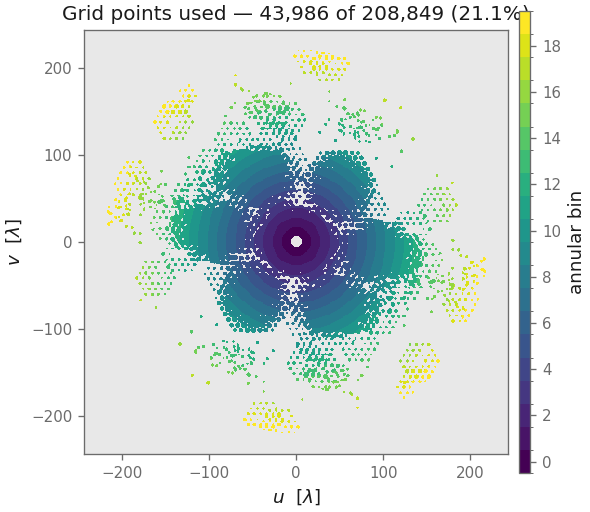

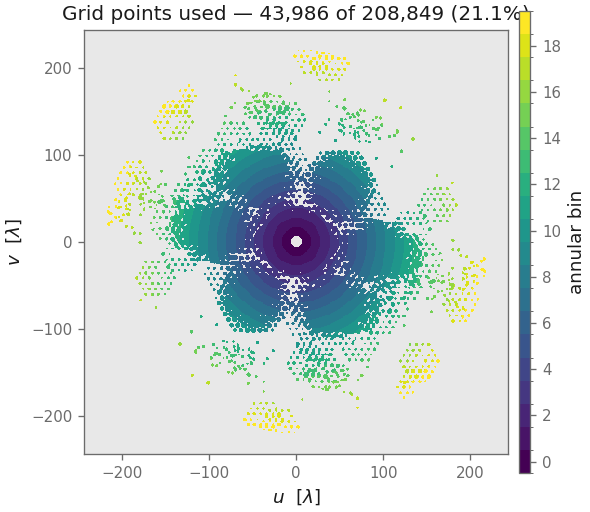

In [3]:
mp.uv_coverage(np.load(cfg.product('bininfo')))

## 2 · Cylindrical power spectrum

$|P(k_\perp, k_\parallel)|$ with the foreground wedge $k_\parallel = (r/r'\nu_c)\,k_\perp$
marked. Power should concentrate below the wedge line; leakage above it is the
thing SCF is meant to suppress.

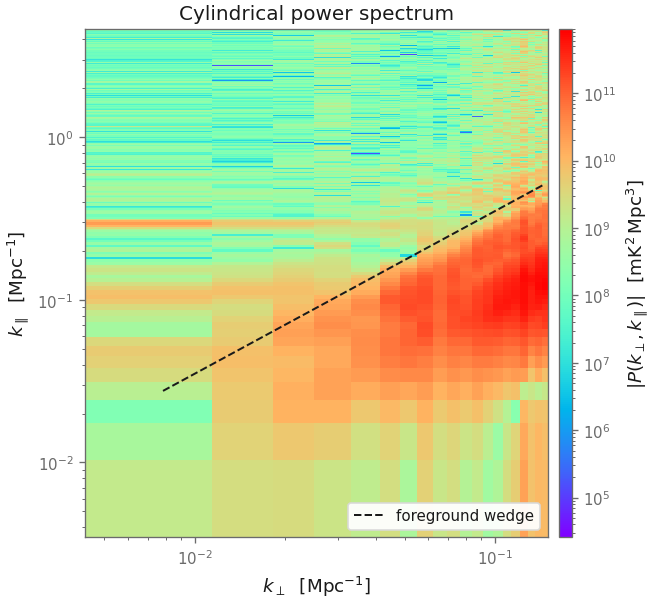

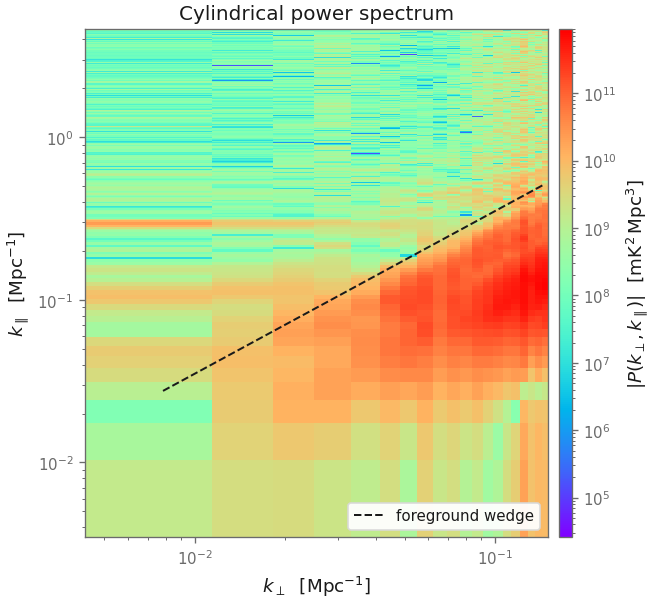

In [4]:
mp.cylindrical_ps(d)

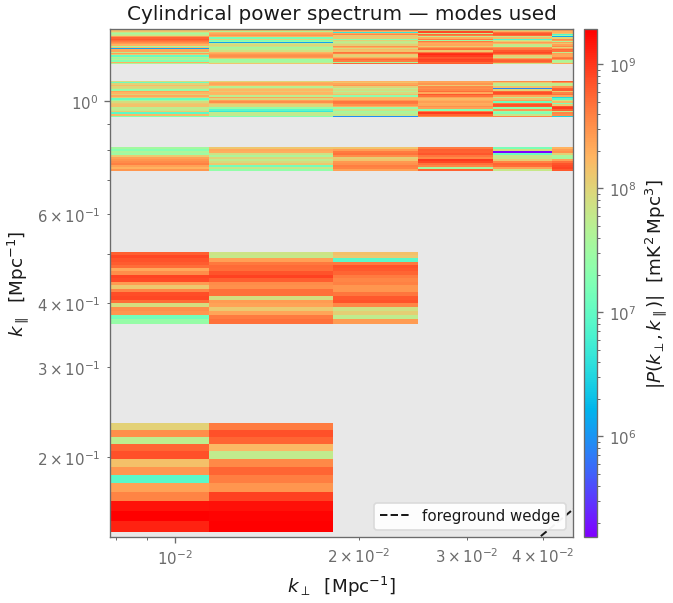

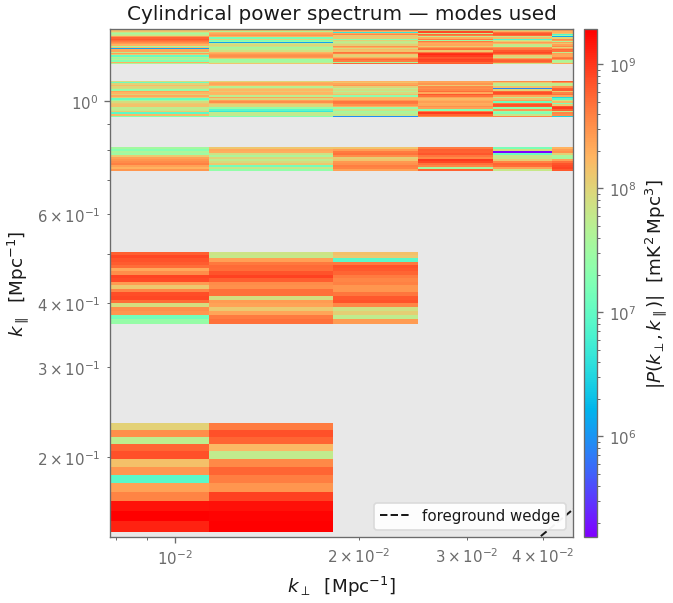

In [5]:
# only the modes that enter the spherical average
mp.cylindrical_ps(d, masked=True)

## 3 · $X$ statistic

$X = P/\delta P_N$ over the selected modes, with a Student-$t$ fit.

`sigma` is the noise calibration: if the noise model were perfect and the field
signal-free, $X$ would have unit variance. `sigma > 1` means the simulated noise
underestimates the real scatter, and stage 5 scales the errors by it.

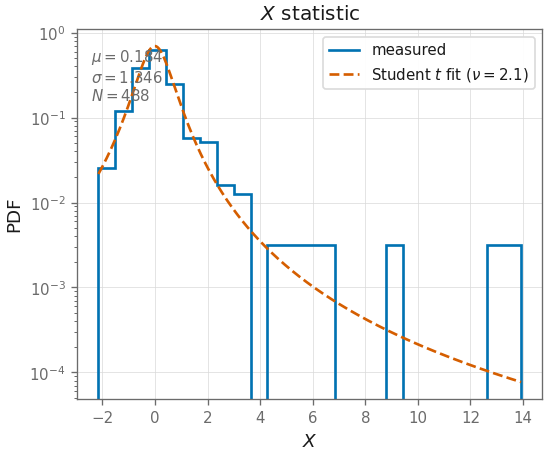

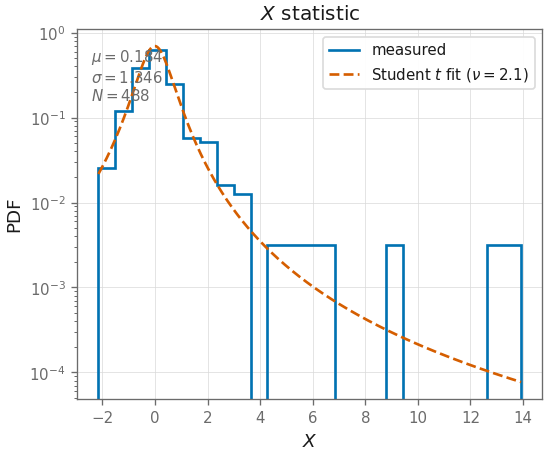

In [6]:
mp.x_statistic(d)

## 4 · Spherical power spectrum

$\Delta^2(k) = k^3 P(k)/2\pi^2$ with $2\sigma$ errors.

Filled markers are detections. **Hollow markers with a downward arrow are consistent
with zero** — the point is an upper limit, not a measurement. Downward triangles are
bins where $\Delta^2 < 0$, i.e. noise-dominated.

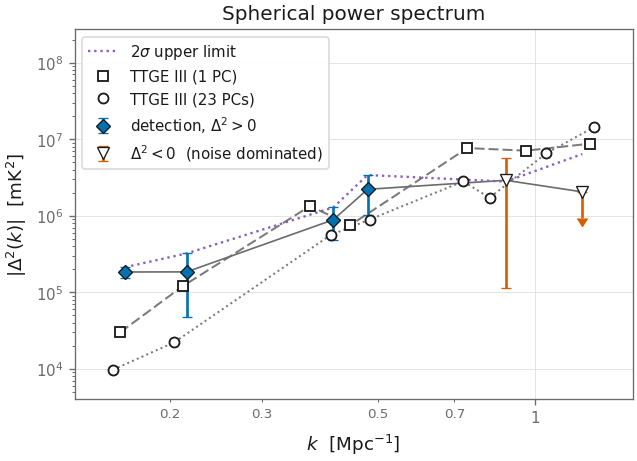

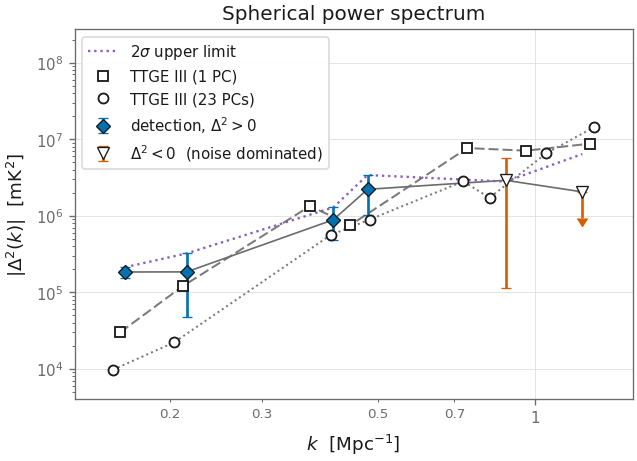

In [7]:
mp.spherical_ps(d, reference=REFERENCE)

In [8]:
# the numbers behind the figure
print(f"{'k [1/Mpc]':>11}  {'Delta^2':>13}  {'2 sigma':>13}  {'SNR':>7}  {'upper limit':>13}")
for i in range(len(d['kk'])):
    print(f"{d['kk'][i]:11.4f}  {d['dk2'][i]:13.4e}  {d['dpk2'][i]:13.4e}"
          f"  {d['snr'][i]:7.3f}  {d['ul'][i]:13.4e}")

  k [1/Mpc]        Delta^2        2 sigma      SNR    upper limit
     0.1645     1.8377e+05     2.8520e+04   12.887     2.1229e+05
     0.2156     1.8437e+05     1.3682e+05    2.695     3.2120e+05
     0.4109     8.8374e+05     3.9792e+05    4.442     1.2817e+06
     0.4780     2.2096e+06     1.1900e+06    3.713     3.3996e+06
     0.8768    -2.8992e+06     2.7869e+06   -2.081     2.7869e+06
     1.2289    -2.0458e+06     6.3823e+06   -0.641     6.3823e+06


## 5 · Comparing runs

This is the figure `Documentation/RA_11.pdf` is made of — the same field processed
several ways, read against each other.

Give each run its own `output_dir` (see `docs/RUNNING.md`) and point at them here.
Colour identifies the run and is assigned in fixed order, so adding a run never
repaints the others.

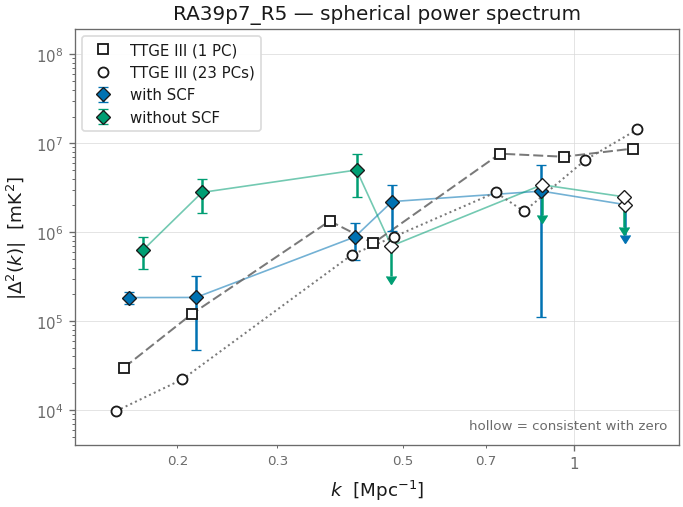

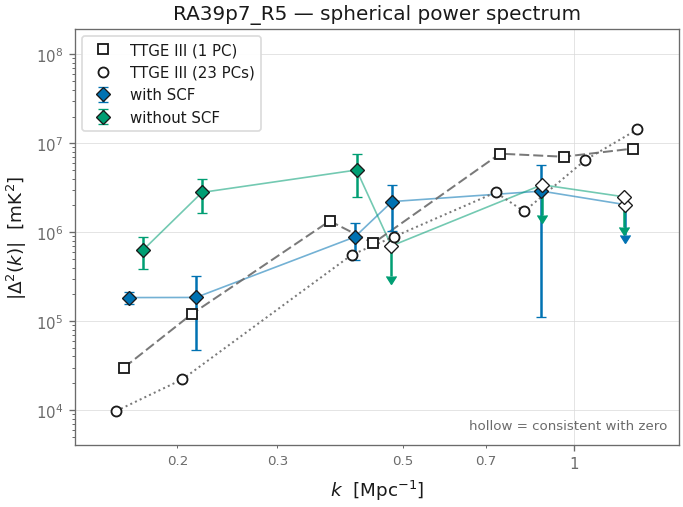

In [9]:
# Comparisons now live in compare_variants.ipynb, which matches the
# with_SCF / without_SCF subdirectory layout written by run_variants.py.
# cfg points at a variant, so the layout's root is its parent.
base = cfg.paths.output_dir.parent
runs = [('with SCF', base / 'with_SCF'), ('without SCF', base / 'without_SCF')]

mp.compare_spherical(runs, title=f'{cfg.index} — spherical power spectrum',
                     reference=REFERENCE)

## 6 · SCF window functions

Diagnostic only — the four supported windows at several smoothing scales. Larger
$N$ means a narrower $k_\parallel$ suppression band,
$[k_\parallel]_F = 2\pi/(r' N \Delta\nu_c)$.

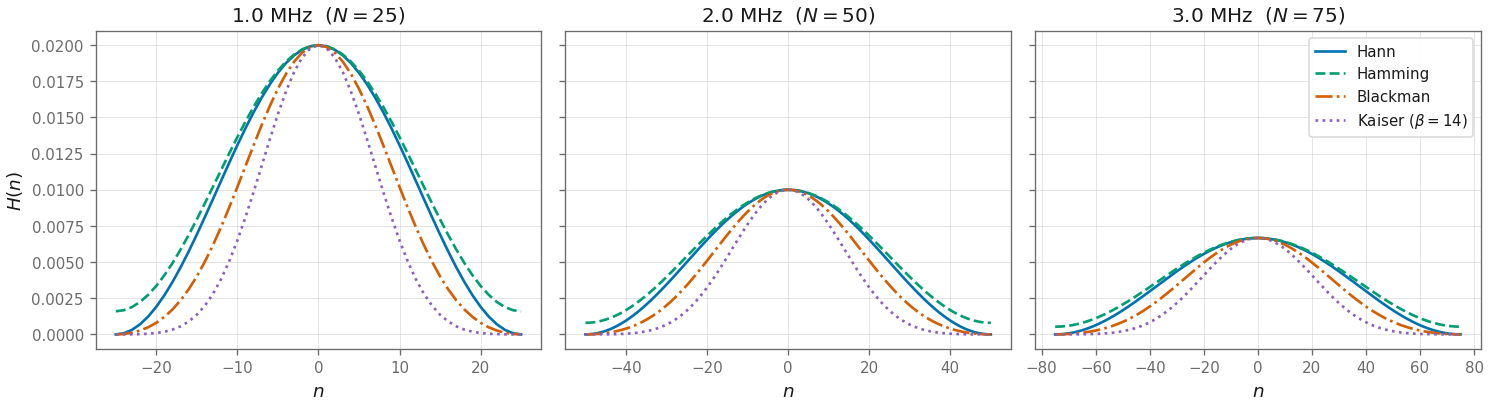

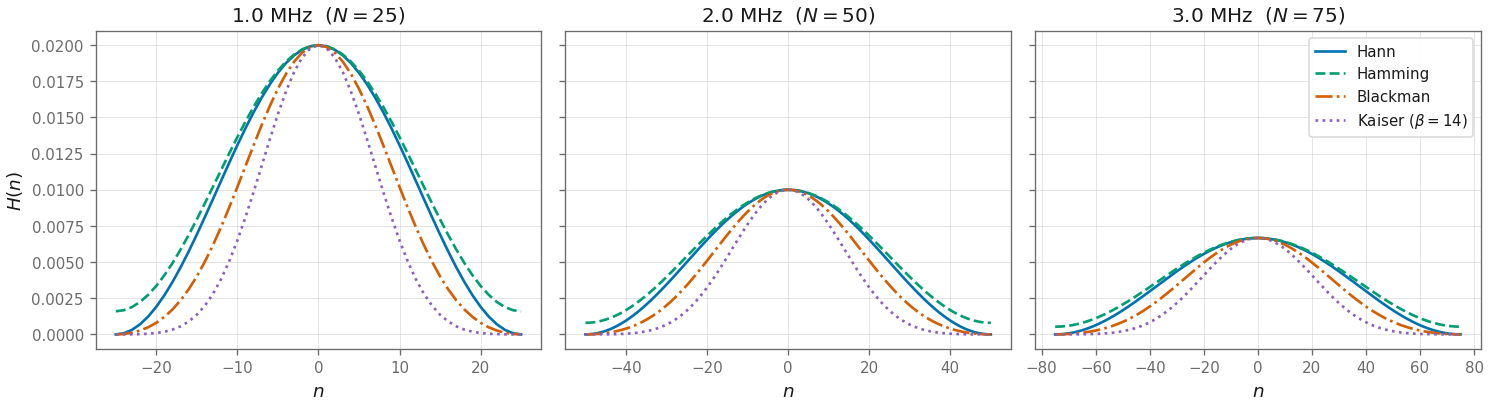

In [10]:
mp.scf_windows(smoothing_mhz=(1.0, cfg.scf.SM_mhz, 3.0),
               dnuc=cfg.observation.dnuc_mhz)

## 7 · Saving

Passing `out=` writes PDF + PNG instead of displaying. For the whole set in one go,
use the batch stage rather than this notebook:

```bash
python pipeline/06_plots.py
```

In [11]:
plot_dir = cfg.out('plots')
plot_dir.mkdir(parents=True, exist_ok=True)

for path in mp.spherical_ps(d, out=plot_dir / f'spherical_ps_{cfg.index}',
                            reference=REFERENCE):
    print('wrote', path)

wrote /scratch3/users/schatterjee/project_MWA/hyperdrive_residual-R5_LF_RA39p7/ps_run_RA_39p7DEG/with_SCF/plots/spherical_ps_RA39p7_R5.pdf
wrote /scratch3/users/schatterjee/project_MWA/hyperdrive_residual-R5_LF_RA39p7/ps_run_RA_39p7DEG/with_SCF/plots/spherical_ps_RA39p7_R5.png
